In [71]:
# ordinal encoder to convert the data of cut,calrity
# one hot encoder for the color
import numpy as np
import pandas as pd

In [72]:
import seaborn as sns 
data=pd.DataFrame(sns.load_dataset('diamonds'))

In [73]:
data.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [74]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [75]:
data['cut'].unique() 
data['color'].unique()
data['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, str): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [76]:
#start

In [77]:
main_data=data.drop(columns=["price"])
lable_data=data[["price"]]

In [78]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from itertools import combinations
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.svm import LinearSVR
import matplotlib.pyplot as plt 

In [79]:
"""
main-pip -- 1st--combos:-how??
                using combinatioes send it to the pargma and convert them into the list by using the custom transformer
            2st--colum_tran  -ordinal (cut,calrity)
                        -one hot for(color)
                        -reminder=passthrough
            3rd--algo--(linearregreeser)
target--price
"""

'\nmain-pip -- 1st--combos:-how??\n                using combinatioes send it to the pargma and convert them into the list by using the custom transformer\n            2st--colum_tran  -ordinal (cut,calrity)\n                        -one hot for(color)\n                        -reminder=passthrough\n            3rd--algo--(linearregreeser)\ntarget--price\n'

In [80]:
columes=main_data.columns.tolist()
length=len(columes)-1

In [81]:
combos=[list(cr) for cr in combinations(columes,length)]
class custom_transformer(BaseEstimator,TransformerMixin):
    def __init__(self,combo=None):
        self.combo=combo
    def fit(self,x,y=None):
        return self
    def transform(self,x):
        if self.combo is not None:
            x_copy=pd.DataFrame(x).copy()
            data_to_send=x_copy[self.combo]
            return data_to_send

In [82]:
def one_hot_encoder_checker(data_recived):
    require=['color']
    return [ i for i in require if i in data_recived.columns]
def ordinal_encoder_checker(data_recived):
    require=['cut','clarity']
    return[i for i in require if i in data_recived.columns]

In [83]:
combos

[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y'],
 ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'z'],
 ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'y', 'z'],
 ['carat', 'cut', 'color', 'clarity', 'depth', 'x', 'y', 'z'],
 ['carat', 'cut', 'color', 'clarity', 'table', 'x', 'y', 'z'],
 ['carat', 'cut', 'color', 'depth', 'table', 'x', 'y', 'z'],
 ['carat', 'cut', 'clarity', 'depth', 'table', 'x', 'y', 'z'],
 ['carat', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'],
 ['cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]

In [84]:
one_hot_encoder=Pipeline([
    ('no_meaning',OneHotEncoder(sparse_output=True,handle_unknown="ignore")),
])

In [85]:
ordinal_encoder=Pipeline([
    ("yes_meaning",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1)),
])

In [86]:
column_tran=ColumnTransformer(transformers=[
    ("one_hot",one_hot_encoder,one_hot_encoder_checker),
    ("ord_enc",ordinal_encoder,ordinal_encoder_checker),
],remainder="passthrough")

In [87]:
main_pipeline=Pipeline(steps=[
    ("combinator",custom_transformer()),
  ("col_tra",column_tran),
    ("algo",LinearSVR())
])

In [88]:
pragma={
    "combinator__combo":combos,
}

In [89]:
grid=GridSearchCV(main_pipeline,pragma,cv=7,error_score='raise')

In [90]:
x_trian,x_test,y_train,y_test=train_test_split(main_data,lable_data,random_state=42,test_size=0.2)

In [91]:
grid.fit(x_trian,y_train)

/home/vedanth-sai-ram/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/vedanth-sai-ram/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/vedanth-sai-ram/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/vedanth-sai-ram/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d arr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVR())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'combinator__combo': [['carat', 'cut', ...], ['carat', 'cut', ...], ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refi

In [92]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('combinator', ...), ('col_tra', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,combo,"['carat', 'cut', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...), ('ord_enc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_t

In [93]:
grid.predict(x_test)

array([-182.14898172, 3242.94986837, 1634.57126575, ...,  527.74825007,
       6560.66781314, 4471.74507668], shape=(10788,))

In [94]:
y_test

,price
1388,559
50052,2201
41645,1238
42377,1304
17244,6901
...,...
44081,1554
23713,633
31375,761
21772,9836


In [95]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_combinator__combo,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,mean_test_score,std_test_score,rank_test_score
0,0.155920,0.056110,0.010220,0.006733,"[carat, cut, color, clarity, depth, table, x, y]","{'combinator__combo': ['carat', 'cut', 'color'...",0.778686,0.779081,0.779547,0.781616,0.760796,0.794676,0.781676,0.779440,0.009182,1
1,0.123975,0.009332,0.007124,0.000184,"[carat, cut, color, clarity, depth, table, x, z]","{'combinator__combo': ['carat', 'cut', 'color'...",0.779834,0.778249,0.778006,0.774254,0.773282,0.792643,0.778852,0.779303,0.005891,2
2,0.137845,0.012984,0.007342,0.000336,"[carat, cut, color, clarity, depth, table, y, z]","{'combinator__combo': ['carat', 'cut', 'color'...",0.771176,0.778870,0.778850,0.774142,0.740591,0.793249,0.779129,0.773715,0.014965,6
3,0.091667,0.002935,0.007573,0.000229,"[carat, cut, color, clarity, depth, x, y, z]","{'combinator__combo': ['carat', 'cut', 'color'...",0.776586,0.776743,0.775972,0.772839,0.763101,0.790623,0.777975,0.776262,0.007507,5
4,0.090263,0.004221,0.007480,0.000186,"[carat, cut, color, clarity, table, x, y, z]","{'combinator__combo': ['carat', 'cut', 'color'...",0.775742,0.778327,0.778064,0.780522,0.762599,0.790529,0.779134,0.777845,0.007624,4
5,0.127669,0.008944,0.006460,0.000397,"[carat, cut, color, depth, table, x, y, z]","{'combinator__combo': ['carat', 'cut', 'color'...",0.757799,0.761223,0.759226,0.759558,0.745536,0.773012,0.759709,0.759438,0.007402,8
6,0.119908,0.003687,0.005924,0.000233,"[carat, cut, clarity, depth, table, x, y, z]","{'combinator__combo': ['carat', 'cut', 'clarit...",0.770333,0.774103,0.772423,0.772081,0.757748,0.789603,0.775567,0.773123,0.008654,7
7,0.125970,0.007500,0.006578,0.000136,"[carat, color, clarity, depth, table, x, y, z]","{'combinator__combo': ['carat', 'color', 'clar...",0.778417,0.780092,0.779772,0.778463,0.762175,0.794412,0.781070,0.779200,0.008677,3
8,0.117995,0.004882,0.006936,0.000129,"[cut, color, clarity, depth, table, x, y, z]","{'combinator__combo': ['cut', 'color', 'clarit...",0.734657,0.737999,0.741412,0.730138,0.707886,0.757441,0.740299,0.735690,0.013822,9


In [96]:
grid.best_params_

{'combinator__combo': ['carat',
  'cut',
  'color',
  'clarity',
  'depth',
  'table',
  'x',
  'y']}

In [97]:
grid.best_score_

np.float64(0.7794398613311005)

In [98]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('combinator', ...), ('col_tra', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,combo,"['carat', 'cut', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...), ('ord_enc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_t

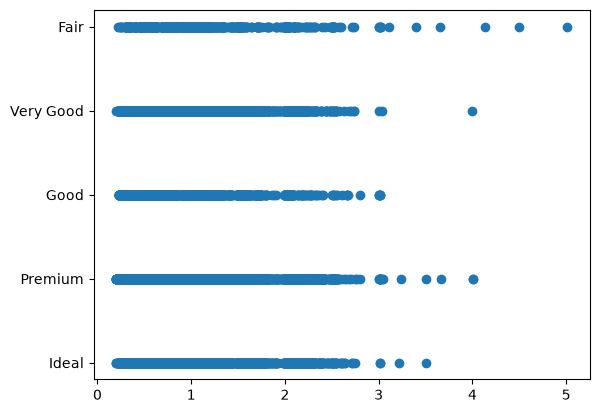

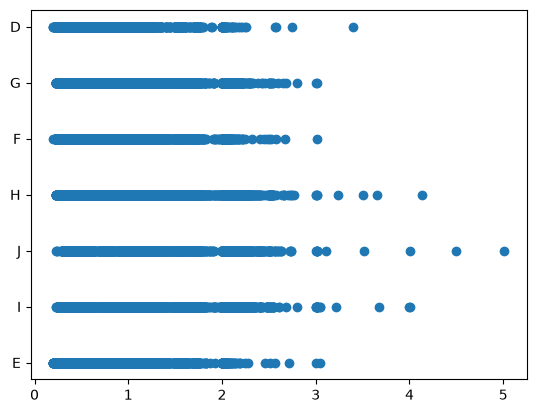

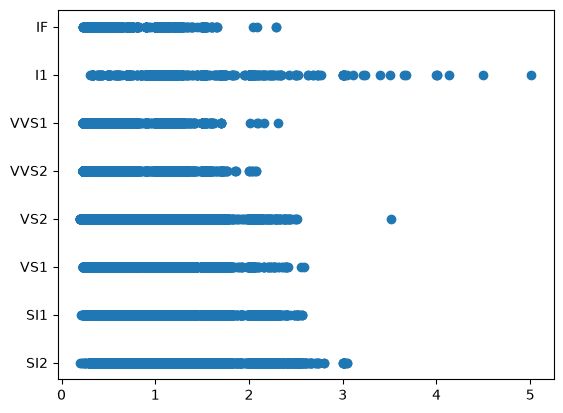

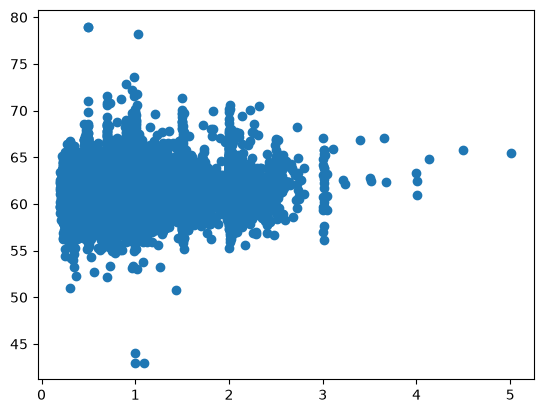

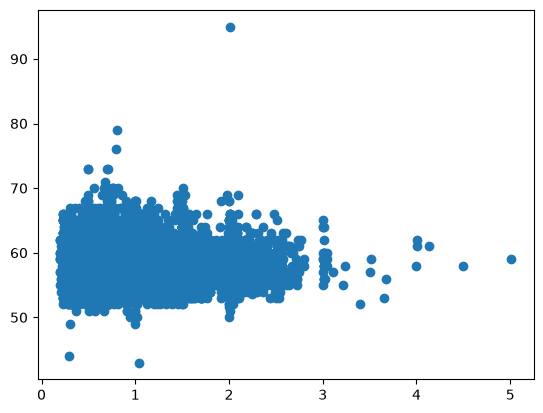

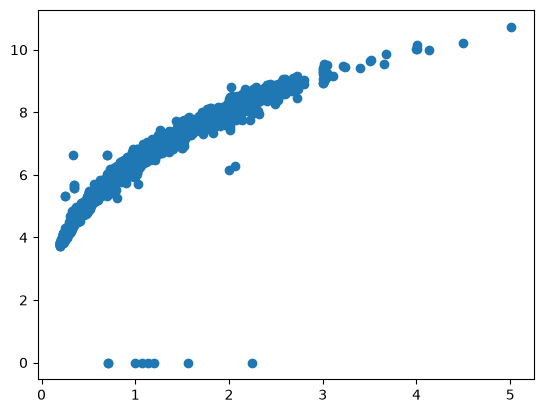

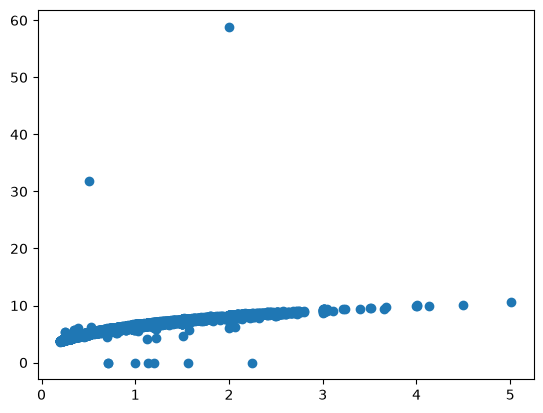

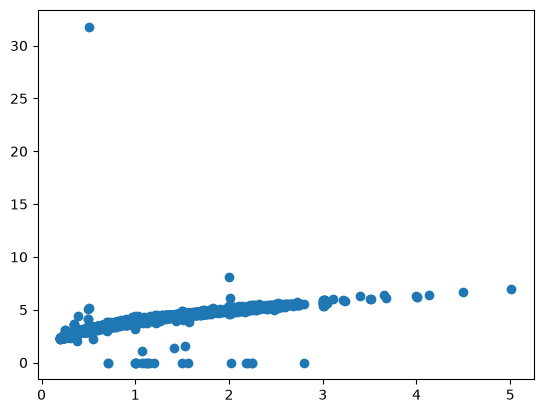

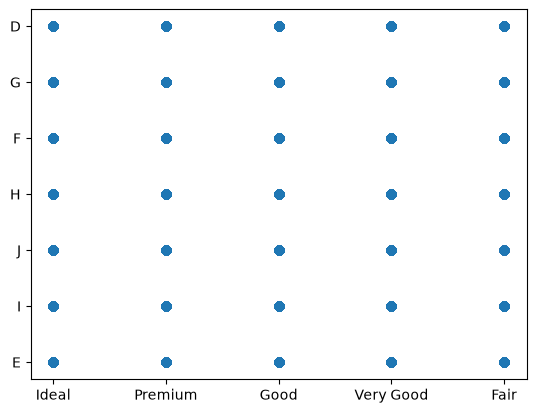

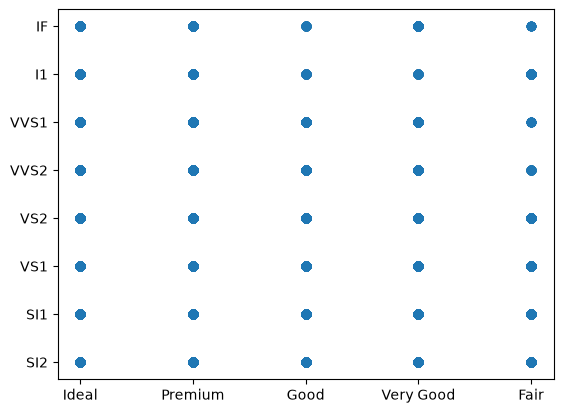

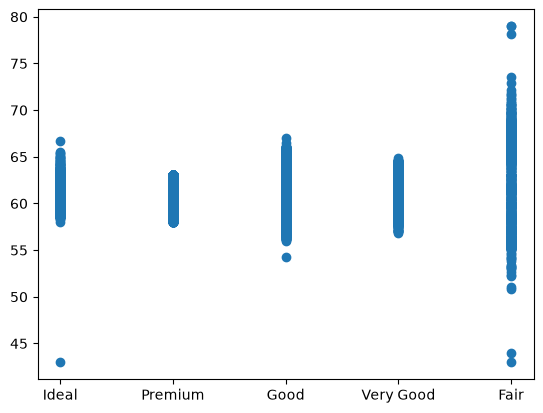

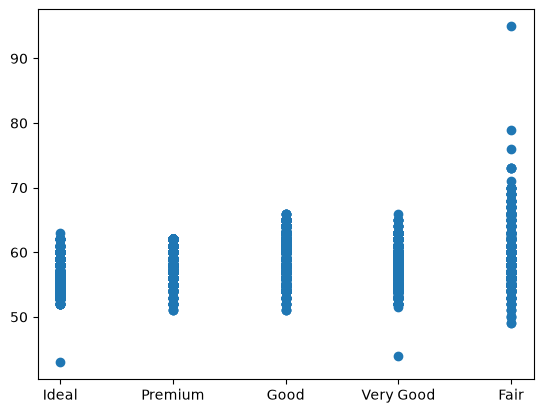

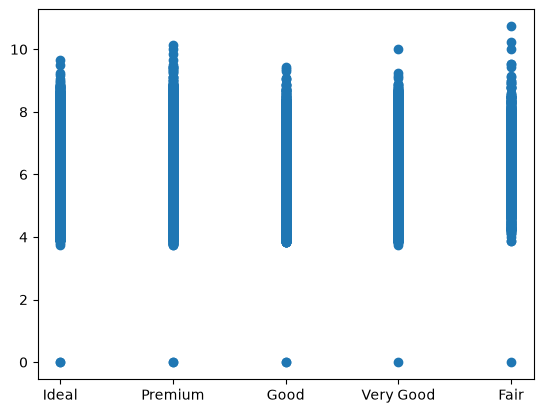

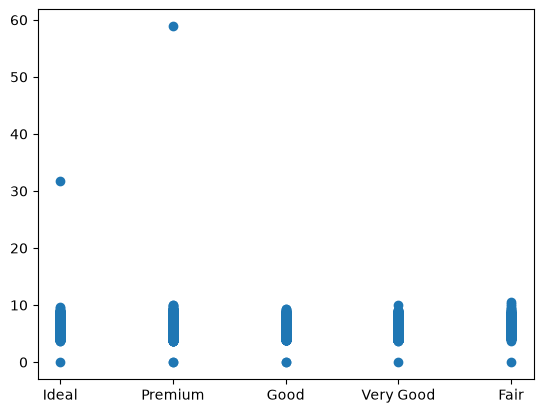

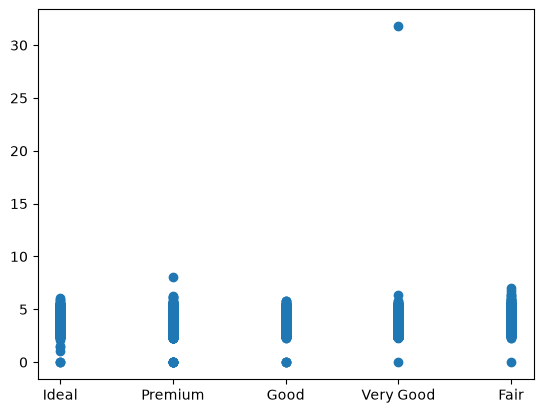

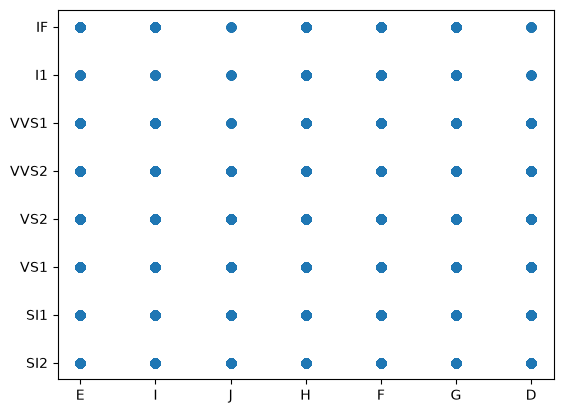

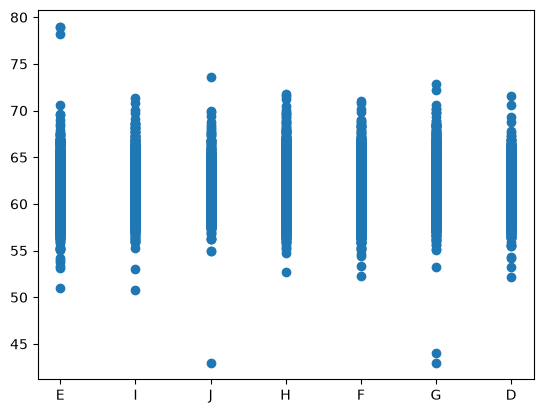

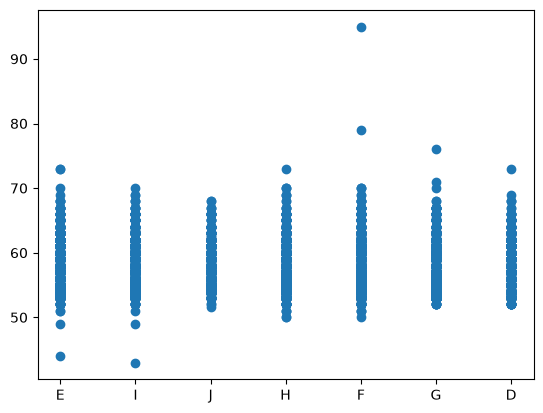

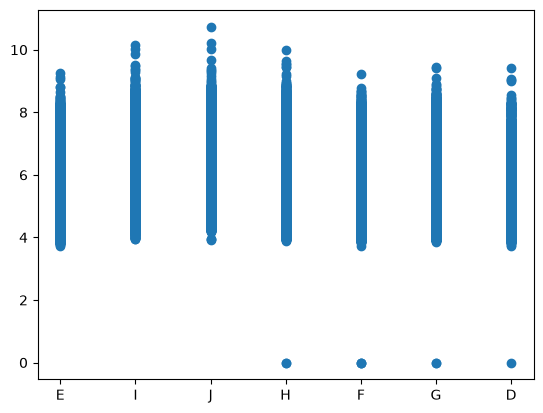

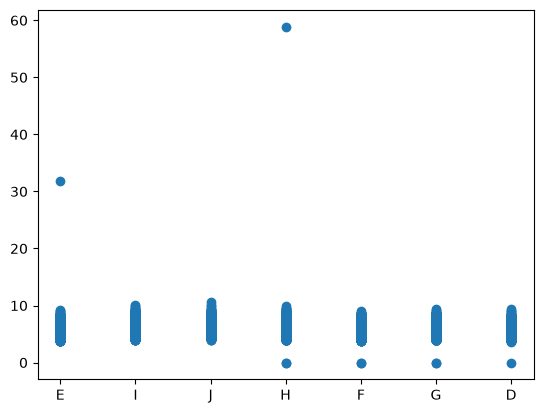

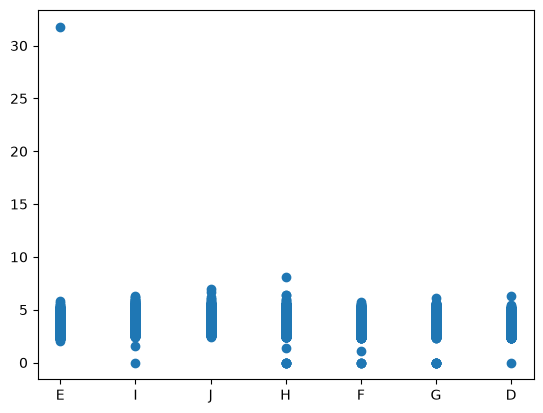

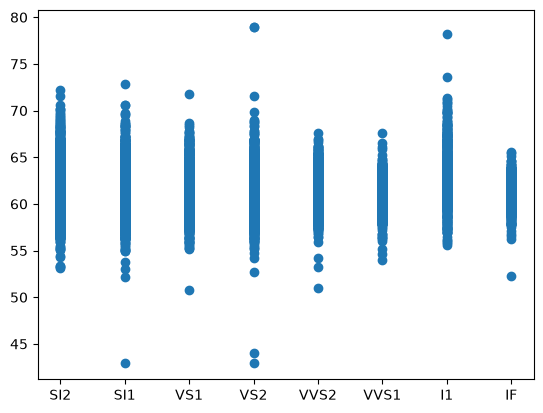

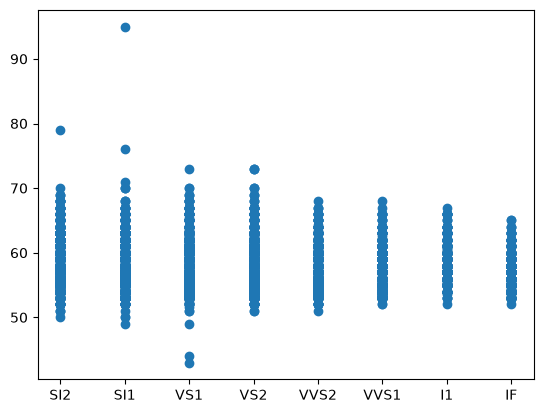

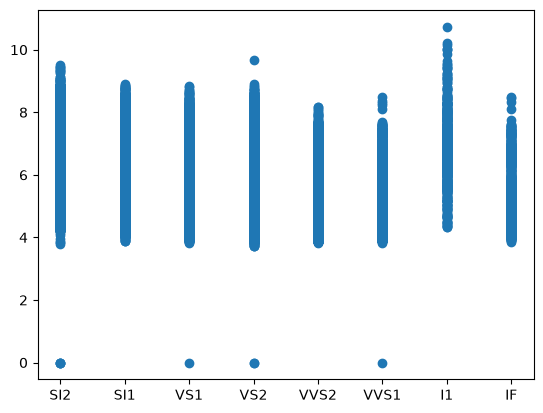

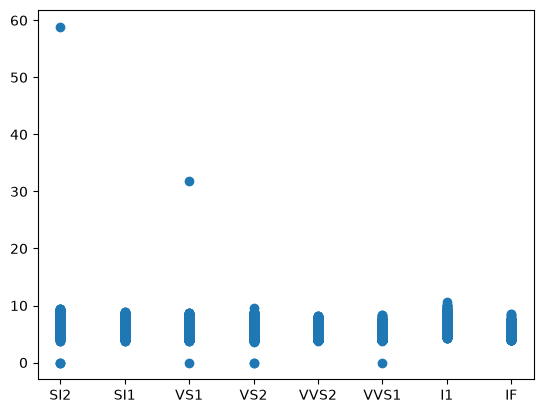

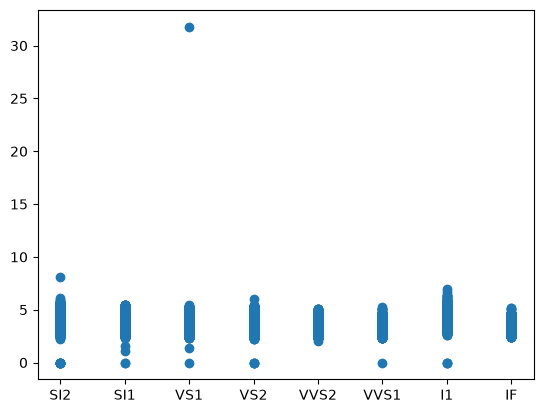

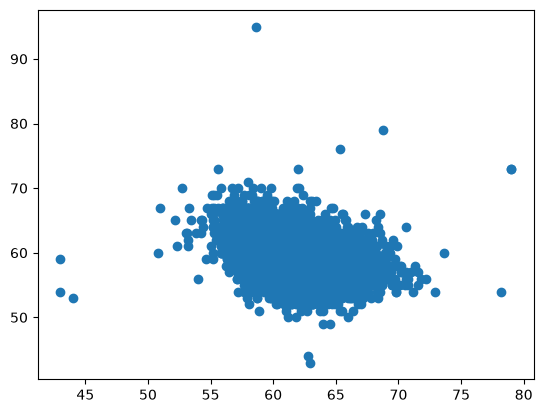

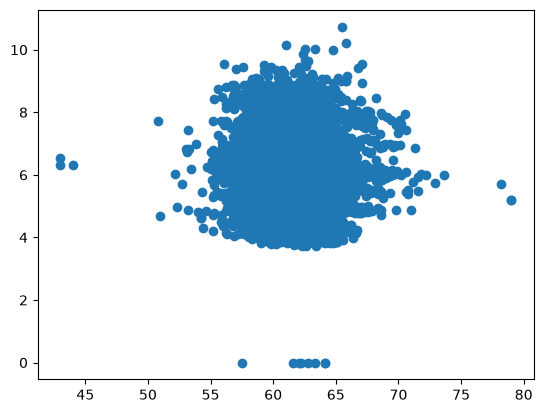

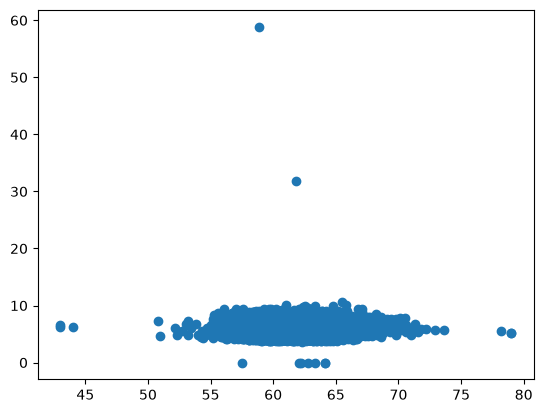

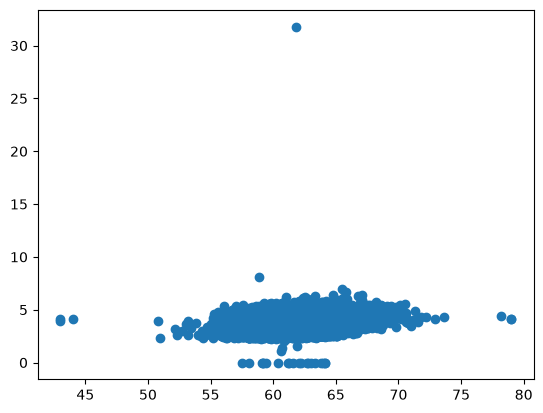

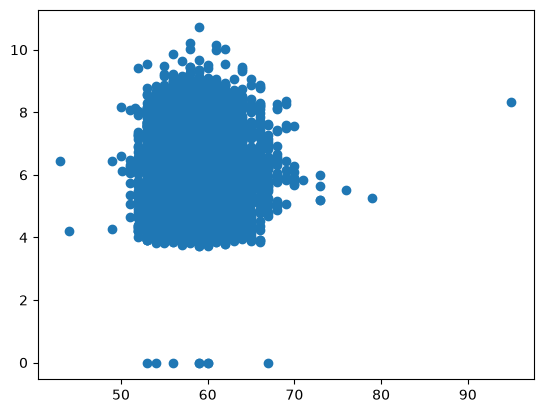

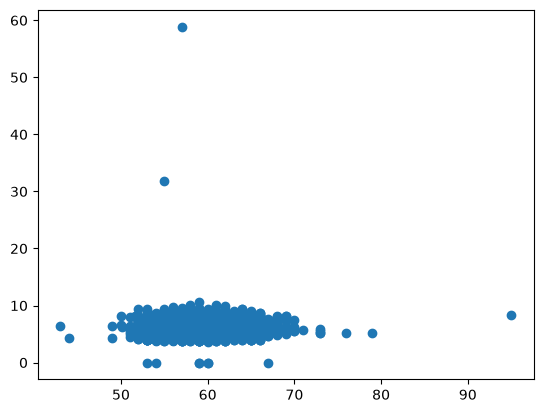

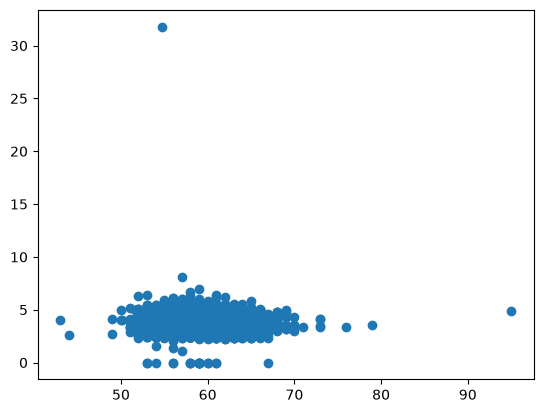

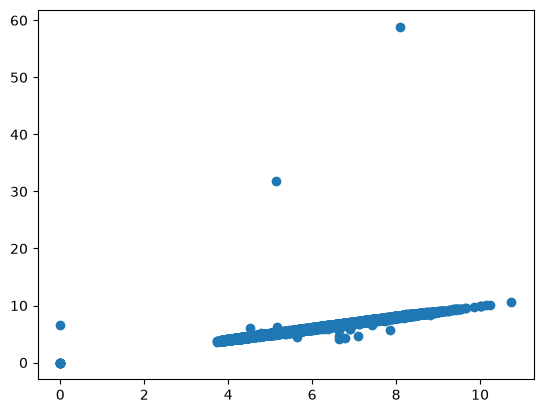

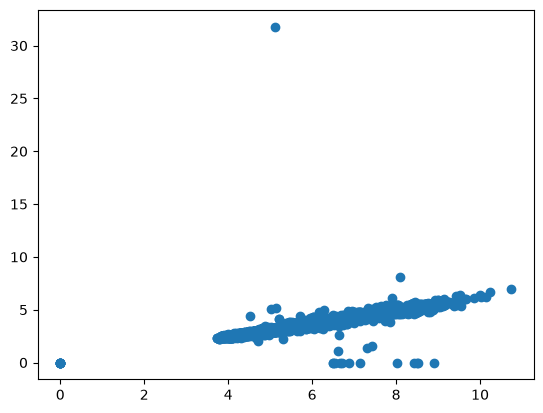

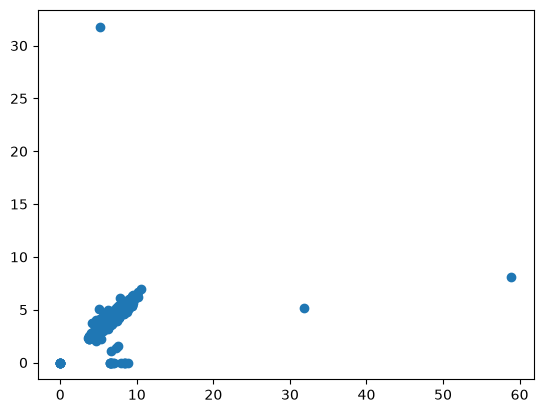

In [99]:
data_vis_combo=[list(i) for i in combinations(main_data,2)]
len(data_vis_combo)
for i in data_vis_combo :
    data1,data2=main_data[i[0]],main_data[i[1]]
    plt.scatter(data1,data2)
    plt.show()